#### Esse projeto tem como objetivo classificar o canto do Pitiguari
Iniciaremos conectando ao Drive e importando algumas bibliotecas necessárias - sempre priorizaremos importar passo a passo para facilitar execução das células individualmente:

> Preparo do ambiente

In [4]:
import requests
import pandas as pd
import os
import librosa
import numpy as np
from tqdm import tqdm
from google.colab import drive # Importa a biblioteca do Google Drive

# -------------------------------------------------------------------
# MONTAR O GOOGLE DRIVE E DEFINIR CAMINHOS
# -------------------------------------------------------------------
try:
    drive.mount('/content/drive')

    # Define os caminhos principais no seu Drive
    DRIVE_PROJECT_PATH = "/content/drive/MyDrive/xenocanto-pitiguari"
    RAW_AUDIO_PATH = os.path.join(DRIVE_PROJECT_PATH, "raw_audio")
    PROCESSED_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, "processed_data")

    # Cria os diretórios se eles não existirem
    os.makedirs(RAW_AUDIO_PATH, exist_ok=True)
    os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

    print(f"✅ Sucesso! Os arquivos serão salvos em: {DRIVE_PROJECT_PATH}")

except Exception as e:
    print(f"❌ Erro ao montar o Google Drive: {e}")
    print("Por favor, autorize o acesso ao Google Drive para continuar.")
    # Se der erro aqui, o script para.
    raise e


Mounted at /content/drive
✅ Sucesso! Os arquivos serão salvos em: /content/drive/MyDrive/xenocanto-pitiguari


> Antes de fazer o download dos arquivos de canto (áudio) do XenoCanto, é necessário:

1.   Criar uma conta em <https://xeno-canto.org/> e receber uma API key
2.   Fazer uma busca e montar um csv com os arquivos desejados para download:

In [ ]:
import time

# -------------------------------------------------------------------
# FASE 1: BUSCAR METADADOS
# -------------------------------------------------------------------
print("\n--- Iniciando Fase 1: Busca de Metadados (API V3 Paginada) ---")

# --- Sua função get_xc_recordings ---
def get_xc_recordings(species_tag_query, api_key, per_page=300, sleep=1.0):
    """
    Baixa todas as páginas de resultados da Xeno-canto API v3 e retorna um DataFrame completo.
    Inclui um atraso entre as chamadas para respeitar os limites de taxa da API.
    """
    base_url = "https://xeno-canto.org/api/3/recordings"
    all_records = []
    page = 1

    print(f"Iniciando a busca por: {species_tag_query}")

    while True:
        params = {
            "query": species_tag_query,
            "key": api_key,
            "per_page": per_page,
            "page": page
        }

        # Tentativa de requisição com tratamento de erro e retentativa simples
        try:
            r = requests.get(base_url, params=params, timeout=10)
            r.raise_for_status() # Lança exceção para códigos de status HTTP ruins (4xx ou 5xx)
        except requests.exceptions.RequestException as e:
            print(f"Erro na requisição da página {page}: {e}. Tentando novamente em {sleep * 2}s...")
            time.sleep(sleep * 2)
            try:
                r = requests.get(base_url, params=params, timeout=10)
                r.raise_for_status()
            except requests.exceptions.RequestException as e2:
                print(f"Falha na segunda tentativa. Pulando página {page}. Erro: {e2}")
                break

        data = r.json()

        # Extrai os registros
        recs = data.get("recordings", [])

        # Parar se não houver mais gravações ou a chave 'recordings' sumir
        if not recs:
            print(f"Nenhum registro encontrado na página {page}. Encerrando a busca.")
            break

        all_records.extend(recs)
        num_pages = int(data.get("numPages", 1))

        print(f"Página {page} de {num_pages} processada. Total de registros coletados: {len(all_records)}")

        # Condição de parada: se a página atual for igual ou maior que o número total de páginas
        if page >= num_pages:
            break

        # Próxima página e atraso
        page += 1
        time.sleep(sleep)

    return pd.DataFrame(all_records)


# --- Configuração e Execução da Busca ---
API_KEY = "<sua-chave>"
query = "gen:Cyclarhis sp:gujanensis q:A" # removemos o "cnt:Brazil" pra aumentar a busca

# Executa a busca
df_all_recs = get_xc_recordings(query, API_KEY)

# --- Processamento dos Dados Baixados ---
metadata_filename = os.path.join(PROCESSED_DATA_PATH, "pitiguari_metadata.csv")

if not df_all_recs.empty:
    print(f"\nBusca concluída. Total de {len(df_all_recs)} gravações baixadas.")

    # Renomear colunas para o padrão do script (mantendo sua correção 'lon')
    df_meta = df_all_recs.rename(columns={
        'lat': 'latitude',
        'lon': 'longitude',
        'q': 'quality',
        'length': 'duration_str'
    })

    # Criar a coluna 'audio_url' (API V3 retorna só o caminho, sem 'https:')
    if 'file' in df_meta.columns:
        df_meta['audio_url'] = df_meta['file'].astype(str)
    else:
        print("Erro: Coluna 'file' não encontrada. Não foi possível criar 'audio_url'.")
        # Inspecione df_all_recs.columns se isso acontecer

    # Colunas que precisamos para as próximas fases
    colunas_desejadas = ['id', 'latitude', 'longitude', 'audio_url', 'duration_str', 'quality']

    # Filtra o DataFrame para ter apenas as colunas úteis
    colunas_existentes = [col for col in colunas_desejadas if col in df_meta.columns]
    df_meta_final = df_meta[colunas_existentes]

    # Remove gravações sem dados de GPS (essencial para a análise)
    df_meta_final = df_meta_final.dropna(subset=['latitude', 'longitude'])
    print(f"Gravações válidas (com GPS): {len(df_meta_final)}")

    # Salva o arquivo final de metadados no Drive
    df_meta_final.to_csv(metadata_filename, index=False)
    print(f"✅ Metadados salvos em: {metadata_filename}")

else:
    print("❌ Nenhuma gravação foi baixada. Verifique sua query ou a chave da API.")


--- Iniciando Fase 1: Busca de Metadados (API V3 Paginada) ---
Iniciando a busca por: gen:Cyclarhis sp:gujanensis q:A
Página 1 de 2 processada. Total de registros coletados: 300
Nenhum registro encontrado na página 2. Encerrando a busca.

Busca concluída. Total de 300 gravações baixadas.
Gravações válidas (com GPS): 279
✅ Metadados salvos em: /content/drive/MyDrive/xenocanto-pitiguari/processed_data/pitiguari_metadata.csv


Conferindo as coluans:

In [ ]:
df_meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             300 non-null    object
 1   gen            300 non-null    object
 2   sp             300 non-null    object
 3   ssp            300 non-null    object
 4   grp            300 non-null    object
 5   en             300 non-null    object
 6   rec            300 non-null    object
 7   cnt            300 non-null    object
 8   loc            300 non-null    object
 9   latitude       279 non-null    object
 10  longitude      279 non-null    object
 11  alt            300 non-null    object
 12  type           300 non-null    object
 13  sex            300 non-null    object
 14  stage          300 non-null    object
 15  method         300 non-null    object
 16  url            300 non-null    object
 17  file           300 non-null    object
 18  file-name      300 non-null   

In [ ]:
import time

# -------------------------------------------------------------------
# FASE 1: BUSCAR METADADOS
# -------------------------------------------------------------------
print("\n--- Iniciando Fase 1: Busca de Metadados (API V3 Paginada) ---")

# --- Sua função get_xc_recordings ---
def get_xc_recordings(species_tag_query, api_key, per_page=300, sleep=1.0):
    """
    Baixa todas as páginas de resultados da Xeno-canto API v3 e retorna um DataFrame completo.
    Inclui um atraso entre as chamadas para respeitar os limites de taxa da API.
    """
    base_url = "https://xeno-canto.org/api/3/recordings"
    all_records = []
    page = 1

    print(f"Iniciando a busca por: {species_tag_query}")

    while True:
        params = {
            "query": species_tag_query,
            "key": api_key,
            "per_page": per_page,
            "page": page
        }

        # Tentativa de requisição com tratamento de erro e retentativa simples
        try:
            r = requests.get(base_url, params=params, timeout=10)
            r.raise_for_status() # Lança exceção para códigos de status HTTP ruins (4xx ou 5xx)
        except requests.exceptions.RequestException as e:
            print(f"Erro na requisição da página {page}: {e}. Tentando novamente em {sleep * 2}s...")
            time.sleep(sleep * 2)
            try:
                r = requests.get(base_url, params=params, timeout=10)
                r.raise_for_status()
            except requests.exceptions.RequestException as e2:
                print(f"Falha na segunda tentativa. Pulando página {page}. Erro: {e2}")
                break

        data = r.json()

        # Extrai os registros
        recs = data.get("recordings", [])

        # Parar se não houver mais gravações ou a chave 'recordings' sumir
        if not recs:
            print(f"Nenhum registro encontrado na página {page}. Encerrando a busca.")
            break

        all_records.extend(recs)
        num_pages = int(data.get("numPages", 1))

        print(f"Página {page} de {num_pages} processada. Total de registros coletados: {len(all_records)}")

        # Condição de parada: se a página atual for igual ou maior que o número total de páginas
        if page >= num_pages:
            break

        # Próxima página e atraso
        page += 1
        time.sleep(sleep)

    return pd.DataFrame(all_records)


# --- Configuração e Execução da Busca ---
API_KEY = "<sua-chave>"
query = "gen:Cyclarhis sp:gujanensis q:A" # removemos o "cnt:Brazil" pra aumentar a busca

# Executa a busca
df_all_recs = get_xc_recordings(query, API_KEY)

# --- Processamento dos Dados Baixados ---
metadata_filename = os.path.join(PROCESSED_DATA_PATH, "pitiguari_metadata.csv")

if not df_all_recs.empty:
    print(f"\nBusca concluída. Total de {len(df_all_recs)} gravações baixadas.")

    # Renomear colunas para o padrão do script (mantendo sua correção 'lon')
    df_meta = df_all_recs.rename(columns={
        'lat': 'latitude',
        'lon': 'longitude',
        'q': 'quality',
        'length': 'duration_str'
    })

    # Criar a coluna 'audio_url' (API V3 retorna só o caminho, sem 'https:')
    if 'file' in df_meta.columns:
        df_meta['audio_url'] = df_meta['file'].astype(str)
    else:
        print("Erro: Coluna 'file' não encontrada. Não foi possível criar 'audio_url'.")
        # Inspecione df_all_recs.columns se isso acontecer

    # Colunas que precisamos para as próximas fases
    colunas_desejadas = ['id', 'latitude', 'longitude', 'audio_url', 'duration_str', 'quality']

    # Filtra o DataFrame para ter apenas as colunas úteis
    colunas_existentes = [col for col in colunas_desejadas if col in df_meta.columns]
    df_meta_final = df_meta[colunas_existentes]

    # Remove gravações sem dados de GPS (essencial para a análise)
    df_meta_final = df_meta_final.dropna(subset=['latitude', 'longitude'])
    print(f"Gravações válidas (com GPS): {len(df_meta_final)}")

    # Salva o arquivo final de metadados no Drive
    df_meta_final.to_csv(metadata_filename, index=False)
    print(f"✅ Metadados salvos em: {metadata_filename}")

else:
    print("❌ Nenhuma gravação foi baixada. Verifique sua query ou a chave da API.")


--- Iniciando Fase 1: Busca de Metadados (API V3 Paginada) ---
Iniciando a busca por: gen:Cyclarhis sp:gujanensis q:A
Página 1 de 2 processada. Total de registros coletados: 300
Nenhum registro encontrado na página 2. Encerrando a busca.

Busca concluída. Total de 300 gravações baixadas.
Gravações válidas (com GPS): 279
✅ Metadados salvos em: /content/drive/MyDrive/xenocanto-pitiguari/processed_data/pitiguari_metadata.csv


Conferindo a estrutura dos dados após nossa seleção:

In [ ]:
df_meta_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 279 entries, 0 to 299
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            279 non-null    object
 1   latitude      279 non-null    object
 2   longitude     279 non-null    object
 3   audio_url     279 non-null    object
 4   duration_str  279 non-null    object
 5   quality       279 non-null    object
dtypes: object(6)
memory usage: 15.3+ KB


Corrigindo o tipo de dados, pois queremos colunas com valores numéricos:

In [ ]:
# -------------------------------------------------------------------
# 3. CORREÇÃO E VALIDAÇÃO DOS TIPOS DE DADOS
# -------------------------------------------------------------------
print("--- Corrigindo tipos de dados ---")

# 1. Converter 'latitude' e 'longitude' de texto (object) para números (float)
df_meta_final['latitude'] = pd.to_numeric(df_meta_final['latitude'])
df_meta_final['longitude'] = pd.to_numeric(df_meta_final['longitude'])

# 2. Definir o caminho do arquivo (caso não esteja definido nesta célula)
PROCESSED_DATA_PATH = "/content/drive/MyDrive/xenocanto-pitiguari/processed_data"
metadata_filename = os.path.join(PROCESSED_DATA_PATH, "pitiguari_metadata.csv")

# 3. --- SALVAR A CORREÇÃO NO DRIVE ---
# Esta é a linha mais importante.
df_meta_final.to_csv(metadata_filename, index=False)

# 4. Conferindo o resultado
print("\n--- info() após correção ---")
df_meta_final.info()
print("\n--- describe() após correção ---")
print(df_meta_final.describe())


print(f"\n✅ Tipos corrigidos e arquivo '{metadata_filename}' salvo no Drive!")

--- Corrigindo tipos de dados ---

--- info() após correção ---
<class 'pandas.core.frame.DataFrame'>
Index: 279 entries, 0 to 299
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            279 non-null    object 
 1   latitude      279 non-null    float64
 2   longitude     279 non-null    float64
 3   audio_url     279 non-null    object 
 4   duration_str  279 non-null    object 
 5   quality       279 non-null    object 
dtypes: float64(2), object(4)
memory usage: 15.3+ KB

--- describe() após correção ---
         latitude   longitude
count  279.000000  279.000000
mean    -6.183677  -64.748052
std     14.694014   17.378166
min    -35.080700 -100.533400
25%    -16.897800  -79.473550
50%     -6.028835  -64.883400
75%      5.341650  -49.272500
max     22.116700  -34.899500

✅ Tipos corrigidos e arquivo '/content/drive/MyDrive/xenocanto-pitiguari/processed_data/pitiguari_metadata.csv' salvo no Drive!


In [ ]:
import pandas as pd
import os

# 2. Definir o caminho do arquivo (caso não esteja definido nesta célula)
PROCESSED_DATA_PATH = "/content/drive/MyDrive/xenocanto-pitiguari/processed_data"
metadata_filename = os.path.join(PROCESSED_DATA_PATH, "pitiguari_metadata.csv")

# --- Carregar o DataFrame ---
try:
    df_meta_final = pd.read_csv(metadata_filename)
except FileNotFoundError:
    print(f"❌ ERRO: Arquivo '{metadata_filename}' não encontrado.")
    raise

# -------------------------------------------------------------------
# 1. Verificando a contagem de NaNs (Nulos)
# -------------------------------------------------------------------
print("--- 1. Contagem de valores NaN (Nulos) por coluna ---")
nan_counts = df_meta_final.isna().sum()
print(nan_counts)

# -------------------------------------------------------------------
# 2. Verificando strings vazias ("") ou brancas (" ")
# -------------------------------------------------------------------
print("\n--- 2. Contagem de strings vazias ou brancas (em colunas de texto) ---")
# O xenocanto as vezes preenche com colunas " "

if len(object_cols) > 0:
    for col in object_cols:
        # Conta strings que são exatamente ""
        empty_strings = (df_meta_final[col] == "").sum()

        # Conta strings que são exatamente " "
        blank_space_strings = (df_meta_final[col] == " ").sum()

        # Conta strings que SÓ contêm espaços (ex: "   ")
        whitespace_strings = 0
        if df_meta_final[col].dtype == 'object': # Checagem extra
            whitespace_strings = df_meta_final[col].str.isspace().sum()

        if empty_strings > 0 or blank_space_strings > 0 or whitespace_strings > 0:
            print(f"\nColuna '{col}':")
            print(f"  Vazias ('')          : {empty_strings}")
            print(f"  Espaço único (' ')   : {blank_space_strings}")
            print(f"  Apenas whitespace ('  '): {whitespace_strings}")
        else:
            print(f"\nColuna '{col}': Limpa (sem strings vazias ou brancas).")
else:
    print("Nenhuma coluna do tipo 'object' (texto) foi encontrada.")

--- 1. Contagem de valores NaN (Nulos) por coluna ---
id              0
latitude        0
longitude       0
audio_url       0
duration_str    0
quality         0
dtype: int64

--- 2. Contagem de strings vazias ou brancas (em colunas de texto) ---

Coluna 'audio_url': Limpa (sem strings vazias ou brancas).

Coluna 'duration_str': Limpa (sem strings vazias ou brancas).

Coluna 'quality': Limpa (sem strings vazias ou brancas).


> Para a etapa seguinte de download dos áudios, incluímos uma amostragem para ter maior compatibilidade com o uso de RAM do ambiente:

In [ ]:

DRIVE_PROJECT_PATH = "/content/drive/MyDrive/xenocanto-pitiguari"
RAW_AUDIO_PATH = os.path.join(DRIVE_PROJECT_PATH, "raw_audio")
PROCESSED_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, "processed_data")

os.makedirs(RAW_AUDIO_PATH, exist_ok=True)
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

# -------------------------------------------------------------------
# CARREGAR METADADOS
# -------------------------------------------------------------------
# Esta parte garante que 'df_meta' sempre exista nesta célula
metadata_filename = os.path.join(PROCESSED_DATA_PATH, "pitiguari_metadata.csv")
try:
    df_meta = pd.read_csv(metadata_filename)
except FileNotFoundError:
    print(f"❌ ERRO: Arquivo '{metadata_filename}' não encontrado.")
    print("Por favor, rode a Célula da Fase 1 primeiro.")
    raise

# -------------------------------------------------------------------
# FASE 2: DOWNLOAD DOS ÁUDIOS (AMOSTRAGEM)
# -------------------------------------------------------------------
print("\n--- Iniciando Fase 2: Download dos Áudios ---")

# !! NOTA SOBRE AMOSTRAGEM !!
# Mantive a amostragem de 100 para o script rodar rápido.
# Se quiser processar TUDO, apenas mude a linha abaixo para:
# df_sample = df_meta.copy()

'''
N_AMOSTRAS = 100
if len(df_meta) > N_AMOSTRAS:
    df_sample = df_meta.sample(n=N_AMOSTRAS, random_state=42)
else:
    df_sample = df_meta.copy()
'''

df_sample = df_meta.copy() # Use todos os dados

print(f"Baixando {len(df_sample)} arquivos de áudio para o Drive...")

downloaded_files_paths = []

for index, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    file_id = row['id']
    audio_url = row['audio_url']

    # O arquivo será salvo permanentemente aqui:
    permanent_audio_path = os.path.join(RAW_AUDIO_PATH, f"{file_id}.mp3")

    # Adiciona o caminho (mesmo que já exista)
    downloaded_files_paths.append({'id': file_id, 'local_path': permanent_audio_path})

    # Otimização: Só baixa se o arquivo ainda NÃO existir no Drive
    if not os.path.exists(permanent_audio_path):
        try:
            with requests.get(audio_url, stream=True) as r:
                r.raise_for_status()
                with open(permanent_audio_path, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        f.write(chunk)
        except Exception as e:
            print(f"Erro ao baixar {audio_url}: {e}")
            downloaded_files_paths.pop() # Remove da lista se o download falhou

print("Download dos áudios concluído.")

# Cria um DataFrame com os caminhos locais
df_paths = pd.DataFrame(downloaded_files_paths)

# Define o nome do arquivo que a Fase 3 espera
paths_filename = os.path.join(PROCESSED_DATA_PATH, "audio_file_paths.csv")

# Salva o arquivo no Drive
df_paths.to_csv(paths_filename, index=False)

print(f"\n✅ Mapa de arquivos locais salvo em: {paths_filename}")


--- Iniciando Fase 2: Download dos Áudios ---
Baixando 279 arquivos de áudio para o Drive...


100%|██████████| 279/279 [03:20<00:00,  1.39it/s]

Download dos áudios concluído.

✅ Mapa de arquivos locais salvo em: /content/drive/MyDrive/xenocanto-pitiguari/processed_data/audio_file_paths.csv


Na extração de features, optamos por trabalhar diretamente com o áudio por ser o mais recomendado pela literatura para a análise que faremos:

In [ ]:
import pandas as pd
import os
import librosa
import numpy as np
from tqdm import tqdm

# Garantindo os paths corretos:

DRIVE_PROJECT_PATH = "/content/drive/MyDrive/xenocanto-pitiguari"
RAW_AUDIO_PATH = os.path.join(DRIVE_PROJECT_PATH, "raw_audio")
PROCESSED_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, "processed_data")

# -------------------------------------------------------------------
# FASE 3: EXTRAÇÃO DE FEATURES
# -------------------------------------------------------------------
print("\n--- Iniciando Fase 3: Extração de Features ---")

def extract_advanced_features(file_path):
    try:
        # 1. Carregar o áudio
        y, sr = librosa.load(file_path, sr=22050)

        # 2. Calcular features básicas e F0
        duration = librosa.get_duration(y=y, sr=sr)

        # Estimação do F0 (Frequência Fundamental)
        f0, voiced_flag, voiced_probs = librosa.pyin(
            y,
            fmin=librosa.note_to_hz('C2'),
            fmax=librosa.note_to_hz('C7')
        )

        # Limpa o F0 removendo silêncio (NaNs)
        f0_cleaned = f0[~np.isnan(f0)]

        # --- Cálculo das Features ---

        # A. Features de Frequência (Tom)
        f0_mean = np.mean(f0_cleaned) if len(f0_cleaned) > 0 else np.nan
        f0_std = np.std(f0_cleaned) if len(f0_cleaned) > 0 else np.nan

        # B. Features de Contorno (Slope)
        f0_slope = np.nan
        if len(f0_cleaned) > 1:
            # Pega os timestamps correspondentes ao F0
            times = librosa.times_like(f0)
            times_cleaned = times[~np.isnan(f0)]
            # Calcula a regressão linear (polinômio de grau 1)
            # O índice [0] pega o 'slope' (inclinação)
            f0_slope = np.polyfit(times_cleaned, f0_cleaned, 1)[0]

        # C. Features de Modulação (Quão "ondulado" é o tom)
        f0_diff = np.abs(np.diff(f0_cleaned))
        fm_rate_mean = np.mean(f0_diff) if len(f0_diff) > 0 else np.nan

        # D. Features Espectrais (Textura do som)
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)

        # E. Entropia / Tonalidade (Quão "ruidoso" vs "puro" é o som)
        # Spectral Flatness (Planicidade) é a "Wiener entropy"
        spectral_flatness = librosa.feature.spectral_flatness(y=y)

        # HNR (Harmonics-to-Noise Ratio) - Proxy via HPSS
        # Separa o som em harmônicos (tom) e percussivos (ruído/ataque)
        y_harm, y_perc = librosa.effects.hpss(y)
        # Calcula a energia RMS de cada um
        rms_harm = np.mean(librosa.feature.rms(y=y_harm))
        rms_perc = np.mean(librosa.feature.rms(y=y_perc))
        # Calcula a HNR em dB. Adiciona 'epsilon' para evitar divisão por zero
        epsilon = 1e-10
        hnr = 20 * np.log10((rms_harm + epsilon) / (rms_perc + epsilon))

        # F. Features de Ritmo (Trill Rate)
        # Detecta o início de cada "nota" (onsets)
        onsets = librosa.onset.onset_detect(y=y, sr=sr, units='time')
        # Taxa de notas por segundo
        trill_rate_hz = len(onsets) / duration if duration > 0 else 0.0

        # Compila o dicionário de resultados
        return {
            "duration": duration,
            "f0_mean": f0_mean,
            "f0_std": f0_std,
            "f0_slope": f0_slope,
            "fm_rate_mean": fm_rate_mean,
            "trill_rate_hz": trill_rate_hz,
            "spectral_centroid_mean": np.mean(spectral_centroid),
            "spectral_bandwidth_mean": np.mean(spectral_bandwidth),
            "spectral_bandwidth_std": np.std(spectral_bandwidth),
            "wiener_entropy_mean": np.mean(spectral_flatness),
            "hnr_mean_db": hnr,
            "error": None
        }

    except Exception as e:
        # Lida com arquivos corrompidos ou vazios
        return {
            "duration": None, "f0_mean": None, "f0_std": None,
            "f0_slope": None, "fm_rate_mean": None, "trill_rate_hz": None,
            "spectral_centroid_mean": None, "spectral_bandwidth_mean": None,
            "spectral_bandwidth_std": None, "wiener_entropy_mean": None,
            "hnr_mean_db": None, "error": str(e)
        }

# --- Loop Principal de Processamento ---

# Carrega o mapa de arquivos que baixamos na Fase 2
paths_filename = os.path.join(PROCESSED_DATA_PATH, "audio_file_paths.csv")
try:
    df_paths = pd.read_csv(paths_filename)
except FileNotFoundError:
    print(f"❌ ERRO: Arquivo '{paths_filename}' não encontrado.")
    print("Por favor, rode a Célula da Fase 2 primeiro.")
    raise

features_list = []
print(f"Processando {len(df_paths)} arquivos de áudio...")

# Itera sobre os arquivos de áudio
for index, row in tqdm(df_paths.iterrows(), total=len(df_paths)):
    file_id = row['id']
    local_path = row['local_path']

    if os.path.exists(local_path):
        features = extract_advanced_features(local_path)
        features['id'] = file_id
        features_list.append(features)
    else:
        print(f"Aviso: Arquivo {local_path} não encontrado. Pulando.")

print("Processamento concluído.")

# -------------------------------------------------------------------
# 4. FASE 4: SALVAR DATASET FINAL
# -------------------------------------------------------------------
print("\n--- Iniciando Fase 4: Geração do Dataset Final ---")

# Cria o DataFrame de features e limpa erros
df_features = pd.DataFrame(features_list)
df_features = df_features.dropna(subset=['duration']) # Remove áudios que deram erro

# Salva as features puras no Drive
features_filename = os.path.join(PROCESSED_DATA_PATH, "pitiguari_features_avancado.csv")
df_features.to_csv(features_filename, index=False)
print(f"Features salvas em: {features_filename}")

# --- Merge com Metadados ---

# Carrega os metadados originais (com GPS e tipos CORRIGIDOS)
metadata_filename = os.path.join(PROCESSED_DATA_PATH, "pitiguari_metadata.csv")
df_meta = pd.read_csv(metadata_filename)

# Garante que os tipos de ID batem para o merge
df_meta['id'] = df_meta['id'].astype(str)
df_features['id'] = df_features['id'].astype(str)

# Juntamos os metadados (GPS) com as features (Áudio)
df_final = pd.merge(df_meta, df_features, on='id')

# Salva o dataset final e completo no Drive
final_data_filename = os.path.join(PROCESSED_DATA_PATH, "dados_completos_analise_avancado.csv")
df_final.to_csv(final_data_filename, index=False)

print(f"\n✅✅✅ Sucesso! Dataset final pronto para análise salvo em:")
print(f"{final_data_filename}")
print(f"\nTotal de amostras no dataset final: {len(df_final)}")
print("\nHead do dataset final:")
print(df_final.head())


--- Iniciando Fase 3: Extração de Features ---
Processando 279 arquivos de áudio...


100%|█████████▉| 278/279 [1:21:53<00:10, 10.53s/it]/tmp/ipython-input-4248270351.py:21: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=22050)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|██████████| 279/279 [1:22:13<00:00, 17.68s/it]

Processamento concluído.

--- Iniciando Fase 4: Geração do Dataset Final ---
Features salvas em: /content/drive/MyDrive/xenocanto-pitiguari/processed_data/pitiguari_features_avancado.csv

✅✅✅ Sucesso! Dataset final pronto para análise salvo em:
/content/drive/MyDrive/xenocanto-pitiguari/processed_data/dados_completos_analise_avancado.csv

Total de amostras no dataset final: 278

Head do dataset final:
        id  latitude  longitude                                audio_url  \
0  1053027   -29.454   -50.5800  https://xeno-canto.org/1053027/download   
1  1050567   -24.000   -47.4523  https://xeno-canto.org/1050567/download   
2  1050566   -24.000   -48.4167  https://xeno-canto.org/1050566/download   
3  1050565   -24.000   -48.4167  https://xeno-canto.org/1050565/download   
4  1050564   -24.000   -48.4167  https://xeno-canto.org/1050564/download   

  duration_str quality   duration      f0_mean      f0_std   f0_slope  \
0         0:13       A  13.523356  1211.442407   63.922055  -7.45

Após essa primeira extração e algumas análises preliminares, acreditamos que o ruído e que arquivos com duração longa e pouco canto interferem na análise, por isso, vamos segmentar os áudios e deixar a duração de 3s (duração média do canto do pitiguari) com um pico centralizado.

Segmentação e re-extração:

In [ ]:
!pip install resampy

In [ ]:
import pandas as pd
import os
import librosa
import numpy as np
from tqdm import tqdm
import gc
from google.colab import drive

# Define os caminhos
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/xenocanto-pitiguari"
RAW_AUDIO_PATH = os.path.join(DRIVE_PROJECT_PATH, "raw_audio")
PROCESSED_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, "processed_data")
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)


# -------------------------------------------------------------------
# EXTRAÇÃO (Recorte de 3s)
# -------------------------------------------------------------------
print("\n--- Iniciando Fase 3: Extração (Recorte de 3s) ---")

def extract_3sec_features(file_path, clip_duration_s=3.0):
    try:
        # 1. Carregar o áudio (Agora o 'resampy' existe!)
        y, sr = librosa.load(file_path, sr=22050, res_type='kaiser_fast')
        if len(y) == 0:
            raise ValueError("Arquivo de áudio vazio.")

        # 2. Recortar o clipe de 3s
        frame_length = 2048
        hop_length = 512
        rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
        peak_frame = np.argmax(rms)
        peak_time_s = librosa.frames_to_time(peak_frame, sr=sr, hop_length=hop_length)

        half_clip = clip_duration_s / 2.0
        start_time_s = max(0, peak_time_s - half_clip)
        end_time_s = min(librosa.get_duration(y=y, sr=sr), peak_time_s + half_clip)

        start_sample = librosa.time_to_samples(start_time_s, sr=sr)
        end_sample = librosa.time_to_samples(end_time_s, sr=sr)

        y_clip = y[start_sample:end_sample]
        del y

        # 3. Calcular Features (no clipe)
        f0, voiced_flag, voiced_probs = librosa.pyin(y_clip, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))
        f0_cleaned = f0[~np.isnan(f0)]

        f0_mean = np.mean(f0_cleaned) if len(f0_cleaned) > 0 else np.nan
        f0_std = np.std(f0_cleaned) if len(f0_cleaned) > 0 else np.nan

        f0_slope = np.nan
        if len(f0_cleaned) > 1:
            times = librosa.times_like(f0)
            times_cleaned = times[~np.isnan(f0)]
            if len(times_cleaned) > 1:
                f0_slope = np.polyfit(times_cleaned, f0_cleaned, 1)[0]

        f0_diff = np.abs(np.diff(f0_cleaned))
        fm_rate_mean = np.mean(f0_diff) if len(f0_diff) > 0 else np.nan
        spectral_centroid = librosa.feature.spectral_centroid(y=y_clip, sr=sr)
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y_clip, sr=sr)
        spectral_flatness = librosa.feature.spectral_flatness(y=y_clip)
        y_harm, y_perc = librosa.effects.hpss(y_clip)
        rms_harm = np.mean(librosa.feature.rms(y=y_harm))
        rms_perc = np.mean(librosa.feature.rms(y=y_perc))
        epsilon = 1e-10
        hnr = 20 * np.log10((rms_harm + epsilon) / (rms_perc + epsilon))
        onsets = librosa.onset.onset_detect(y=y_clip, sr=sr, units='time')
        trill_rate_hz = len(onsets) / clip_duration_s

        del y_clip, f0, f0_cleaned, y_harm, y_perc

        return {
            "f0_mean": f0_mean, "f0_std": f0_std, "f0_slope": f0_slope,
            "fm_rate_mean": fm_rate_mean, "trill_rate_hz": trill_rate_hz,
            "spectral_centroid_mean": np.mean(spectral_centroid),
            "spectral_bandwidth_mean": np.mean(spectral_bandwidth),
            "spectral_bandwidth_std": np.std(spectral_bandwidth),
            "wiener_entropy_mean": np.mean(spectral_flatness),
            "hnr_mean_db": hnr, "error": None
        }
    except Exception as e:
        return {
            "f0_mean": None, "f0_std": None, "f0_slope": None,
            "fm_rate_mean": None, "trill_rate_hz": None,
            "spectral_centroid_mean": None, "spectral_bandwidth_mean": None,
            "spectral_bandwidth_std": None, "wiener_entropy_mean": None,
            "hnr_mean_db": None, "error": str(e) # Salva o erro
        }

# --- Loop Principal ---
paths_filename = os.path.join(PROCESSED_DATA_PATH, "audio_file_paths.csv")
df_paths = pd.read_csv(paths_filename)
features_list = []
print(f"Processando {len(df_paths)} arquivos (Recorte de 3s)...")

for index, row in tqdm(df_paths.iterrows(), total=len(df_paths)):
    file_id = row['id']
    local_path = row['local_path']
    if os.path.exists(local_path):
        features = extract_3sec_features(local_path)
        features['id'] = file_id
        features_list.append(features)
    else:
        features_list.append({'id': file_id, 'error': 'Arquivo não encontrado'})
    if (index + 1) % 10 == 0:
        gc.collect()
gc.collect()
print("Processamento concluído.")

# -------------------------------------------------------------------
# SALVAR DATASET FINAL (Recorte de 3s)
# -------------------------------------------------------------------
print("\n--- Iniciando Fase 4: Geração do Dataset (Recorte de 3s) ---")
df_features = pd.DataFrame(features_list)

# Agora o 'dropna' vai funcionar como esperado
df_features_cleaned = df_features.dropna(subset=['f0_mean'])

features_filename = os.path.join(PROCESSED_DATA_PATH, "pitiguari_features_3sec_clip.csv")
df_features_cleaned.to_csv(features_filename, index=False)
print(f"Features (Recorte de 3s) salvas em: {features_filename}")

# --- Merge com Metadados ---
metadata_filename = os.path.join(PROCESSED_DATA_PATH, "pitiguari_metadata.csv")
df_meta = pd.read_csv(metadata_filename)
df_meta['id'] = df_meta['id'].astype(str)
df_features_cleaned['id'] = df_features_cleaned['id'].astype(str)

df_final = pd.merge(df_meta, df_features_cleaned, on='id', how='inner')

final_data_filename = os.path.join(PROCESSED_DATA_PATH, "dados_completos_analise_3sec_clip.csv")
df_final.to_csv(final_data_filename, index=False)

print(f"\n✅✅✅ Sucesso! Dataset final (Recorte de 3s) salvo em:")
print(f"{final_data_filename}")
print(f"\nTotal de amostras no dataset: {len(df_final)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Iniciando Fase 3: Extração (Recorte de 3s) ---
Processando 279 arquivos (Recorte de 3s)...


100%|█████████▉| 278/279 [09:48<00:01,  1.96s/it]/tmp/ipython-input-714236029.py:35: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=22050, res_type='kaiser_fast')
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|██████████| 279/279 [09:52<00:00,  2.12s/it]


Processamento concluído.

--- Iniciando Fase 4: Geração do Dataset (Recorte de 3s) ---
Features (Recorte de 3s) salvas em: /content/drive/MyDrive/xenocanto-pitiguari/processed_data/pitiguari_features_3sec_clip.csv

✅✅✅ Sucesso! Dataset final (Recorte de 3s) salvo em:
/content/drive/MyDrive/xenocanto-pitiguari/processed_data/dados_completos_analise_3sec_clip.csv

Total de amostras no dataset: 273


/tmp/ipython-input-714236029.py:140: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features_cleaned['id'] = df_features_cleaned['id'].astype(str)


In [5]:
import pandas as pd
import os

PROCESSED_DATA_PATH = "/content/drive/MyDrive/xenocanto-pitiguari/processed_data"
debug_filename = os.path.join(PROCESSED_DATA_PATH, "dados_completos_analise_3sec_clip.csv")

try:
    df_debug = pd.read_csv(debug_filename)
except FileNotFoundError:
    print(f"❌ ERRO: Arquivo '{debug_filename}' não encontrado.")
    raise

print(f"Dataset de depuração (3s) carregado com {len(df_debug)} linhas.")
print("\n--- Contagem de Sucessos vs. Falhas ---")
sucessos = df_debug['error'].isna().sum()
falhas = len(df_debug) - sucessos
print(f"Arquivos processados com SUCESSO: {sucessos}")
print(f"Arquivos que FALHARAM: {falhas}")

if falhas > 0:
    print("\n--- Principais Mensagens de Erro ---")
    print(df_debug['error'].value_counts())

Dataset de depuração (3s) carregado com 273 linhas.

--- Contagem de Sucessos vs. Falhas ---
Arquivos processados com SUCESSO: 273
Arquivos que FALHARAM: 0


Testando a hipótese clinal:

Dataset LIMPO (Recorte de 3s) carregado. Total de amostras: 273

--- Gerando gráficos da hipótese clinal (Dados Limpos) ---


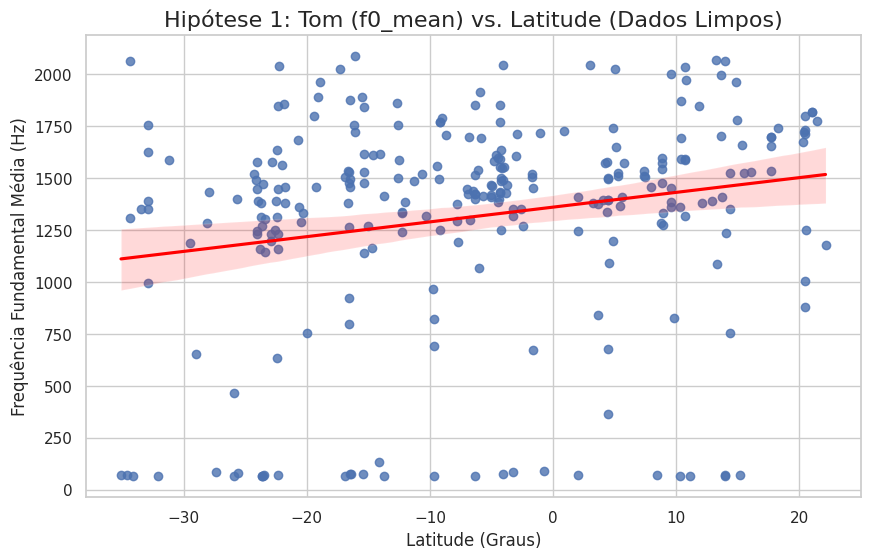

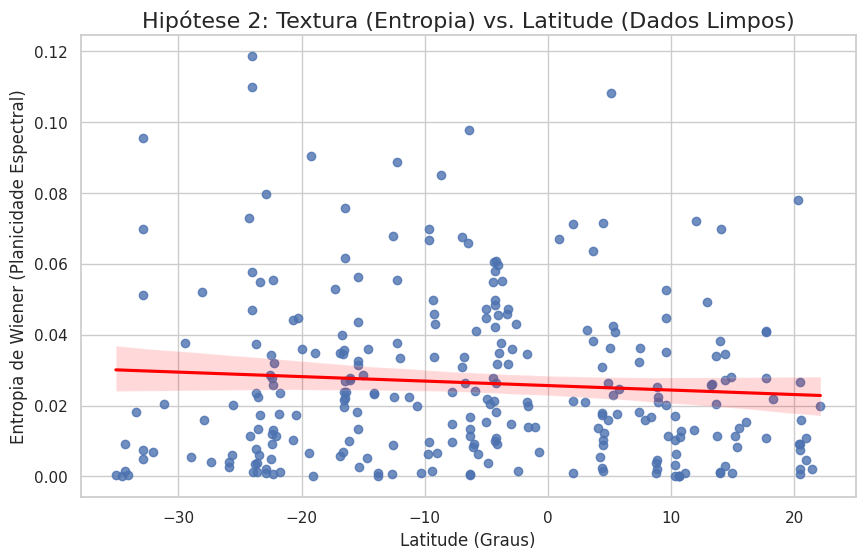

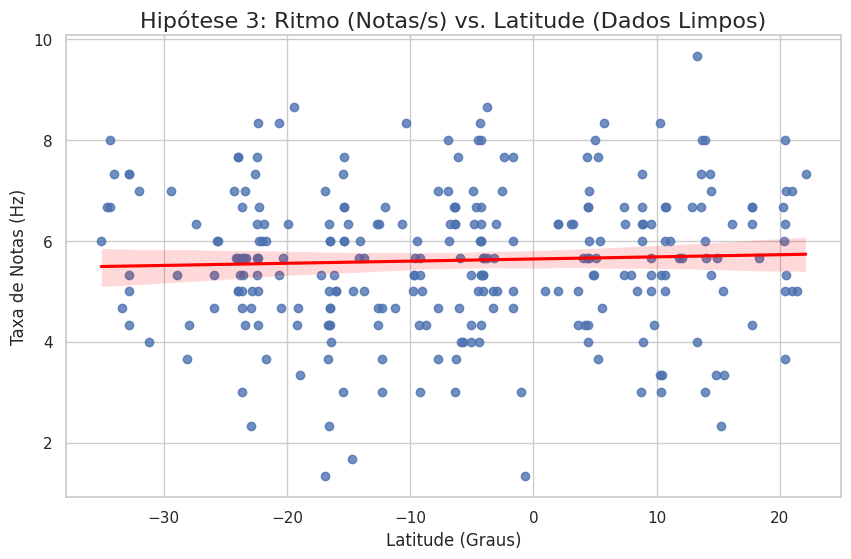


--- Gerando Mapa de Correlação (Dados Limpos) ---


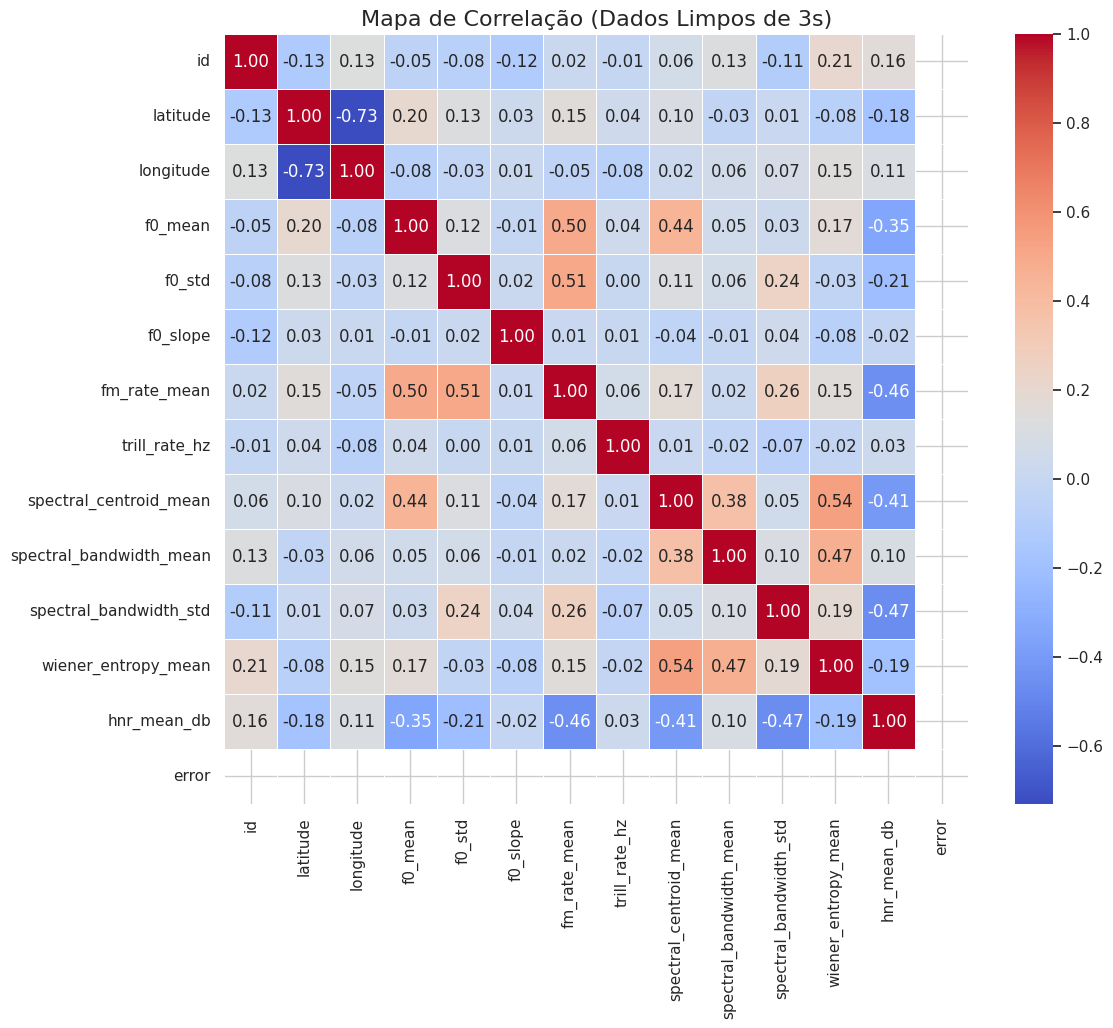

In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------
# CARREGAR O DATASET (Recorte de 3s)
# -------------------------------------------------------------------
PROCESSED_DATA_PATH = "/content/drive/MyDrive/xenocanto-pitiguari/processed_data"
final_data_filename = os.path.join(PROCESSED_DATA_PATH, "dados_completos_analise_3sec_clip.csv")

try:
    df_analysis = pd.read_csv(final_data_filename)
except FileNotFoundError:
    print(f"❌ ERRO: Arquivo '{final_data_filename}' não encontrado.")
    raise

print(f"Dataset LIMPO (Recorte de 3s) carregado. Total de amostras: {len(df_analysis)}")

# -------------------------------------------------------------------
# ANÁLISE VISUAL (EDA) - TESTANDO A HIPÓTESE CLINAL
# -------------------------------------------------------------------
print("\n--- Gerando gráficos da hipótese clinal (Dados Limpos) ---")
sns.set_theme(style="whitegrid")

# Hipótese 1: Frequência (f0_mean) vs. Latitude
# Agora esperamos ver uma correlação!
plt.figure(figsize=(10, 6))
sns.regplot(data=df_analysis, x='latitude', y='f0_mean', line_kws={"color": "red"})
plt.title('Hipótese 1: Tom (f0_mean) vs. Latitude (Dados Limpos)', fontsize=16)
plt.ylabel('Frequência Fundamental Média (Hz)')
plt.xlabel('Latitude (Graus)')
plt.show()

# Hipótese 2: Textura (wiener_entropy_mean) vs. Latitude
plt.figure(figsize=(10, 6))
sns.regplot(data=df_analysis, x='latitude', y='wiener_entropy_mean', line_kws={"color": "red"})
plt.title('Hipótese 2: Textura (Entropia) vs. Latitude (Dados Limpos)', fontsize=16)
plt.ylabel('Entropia de Wiener (Planicidade Espectral)')
plt.xlabel('Latitude (Graus)')
plt.show()

# Hipótese 3: Ritmo (trill_rate_hz) vs. Latitude
plt.figure(figsize=(10, 6))
sns.regplot(data=df_analysis, x='latitude', y='trill_rate_hz', line_kws={"color": "red"})
plt.title('Hipótese 3: Ritmo (Notas/s) vs. Latitude (Dados Limpos)', fontsize=16)
plt.ylabel('Taxa de Notas (Hz)')
plt.xlabel('Latitude (Graus)')
plt.show()

# -------------------------------------------------------------------
# MAPA DE CORRELAÇÃO (Dados Limpos)
# -------------------------------------------------------------------
print("\n--- Gerando Mapa de Correlação (Dados Limpos) ---")

numeric_cols = df_analysis.select_dtypes(include=np.number)
plt.figure(figsize=(12, 10))
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title('Mapa de Correlação (Dados Limpos de 3s)', fontsize=16)
plt.show()

Aplicando a PCA:

Amostras limpas prontas para PCA: 273

Variância explicada por PC1: 27.11%
Variância explicada por PC2: 16.50%
Total explicado por 2 PCs: 43.61%

--- Gerando o Gráfico de Variação Clinal (PCA com Dados Limpos) ---


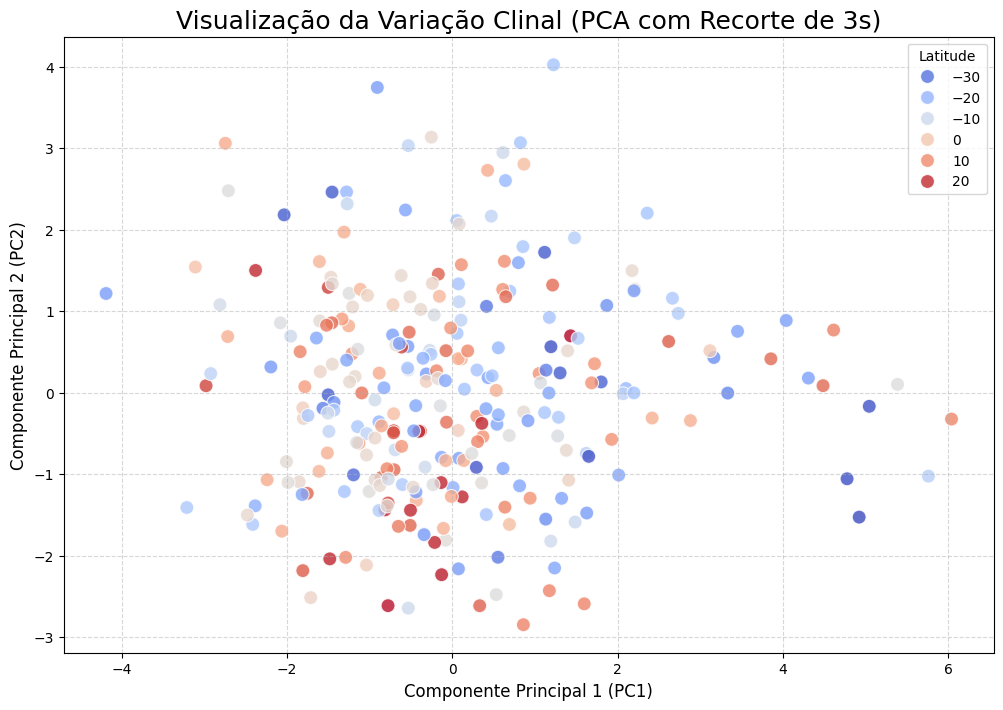

In [6]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------------------------------------------------
# CARREGAR O DATASET (Recorte de 3s)
# -------------------------------------------------------------------
PROCESSED_DATA_PATH = "/content/drive/MyDrive/xenocanto-pitiguari/processed_data"
final_data_filename = os.path.join(PROCESSED_DATA_PATH, "dados_completos_analise_3sec_clip.csv")

try:
    df_analysis = pd.read_csv(final_data_filename)
except FileNotFoundError:
    print(f"❌ ERRO: Arquivo '{final_data_filename}' não encontrado.")
    raise

# Define as features que usaremos para o PCA
# (Todas as 10 features, já que 'duration' foi removida)
features_to_analyze = [
    "f0_mean", "f0_std", "f0_slope", "fm_rate_mean",
    "trill_rate_hz", "spectral_centroid_mean", "spectral_bandwidth_mean",
    "spectral_bandwidth_std", "wiener_entropy_mean", "hnr_mean_db"
]

# Limpa quaisquer NaNs restantes
df_cleaned = df_analysis.dropna(subset=features_to_analyze).copy()
print(f"Amostras limpas prontas para PCA: {len(df_cleaned)}")

# -------------------------------------------------------------------
# PADRONIZAÇÃO (SCALING) - ETAPA CRÍTICA!
# -------------------------------------------------------------------
# O PCA exige que todas as features estejam na mesma escala.
X = df_cleaned[features_to_analyze]
y_latitude = df_cleaned['latitude']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------------------------------------------
# APLICAR O PCA
# -------------------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"\nVariância explicada por PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variância explicada por PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total explicado por 2 PCs: {np.sum(pca.explained_variance_ratio_):.2%}")

# -------------------------------------------------------------------
# VISUALIZAR O GRADIENTE CLINAL (O GRÁFICO PRINCIPAL!)
# -------------------------------------------------------------------
# Cria um novo DataFrame para plotar
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['latitude'] = y_latitude.values

print("\n--- Gerando o Gráfico de Variação Clinal (PCA com Dados Limpos) ---")

plt.figure(figsize=(12, 8))

# Este é o gráfico que valida a "ausência de dialetos"
# e a "presença de um gradiente"
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='latitude',
    palette='coolwarm',  # Gradiente Azul-Vermelho
    legend='auto',
    s=100,
    alpha=0.8
)

plt.title('Visualização da Variação Clinal (PCA com Recorte de 3s)', fontsize=18)
plt.xlabel('Componente Principal 1 (PC1)', fontsize=12)
plt.ylabel('Componente Principal 2 (PC2)', fontsize=12)
plt.legend(title='Latitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

O gráfico mostra uma única nuvem de pontos grande e contínua. Você não vê um aglomerado de pontos azuis em um canto e um aglomerado de pontos vermelhos em outro. Isso confirma visualmente a primeira parte da literatura: a variação não se manifesta como dialetos discretos e separados.

O que os componentes significam?

--- Cargas dos Componentes Principais (PCA Loadings) ---
O que o PC1 e o PC2 realmente significam?

      f0_mean    f0_std  f0_slope  fm_rate_mean  trill_rate_hz  \
PC1 -0.382191 -0.275358  0.011804     -0.424629      -0.000765   
PC2 -0.051004 -0.345847 -0.123561     -0.343914      -0.029343   

     spectral_centroid_mean  spectral_bandwidth_mean  spectral_bandwidth_std  \
PC1               -0.420000                -0.201889               -0.287906   
PC2                0.360485                 0.525329               -0.202809   

     wiener_entropy_mean  hnr_mean_db  
PC1            -0.336337     0.429519  
PC2             0.487775     0.241675  

--- Visualização (Heatmap) dos Loadings ---


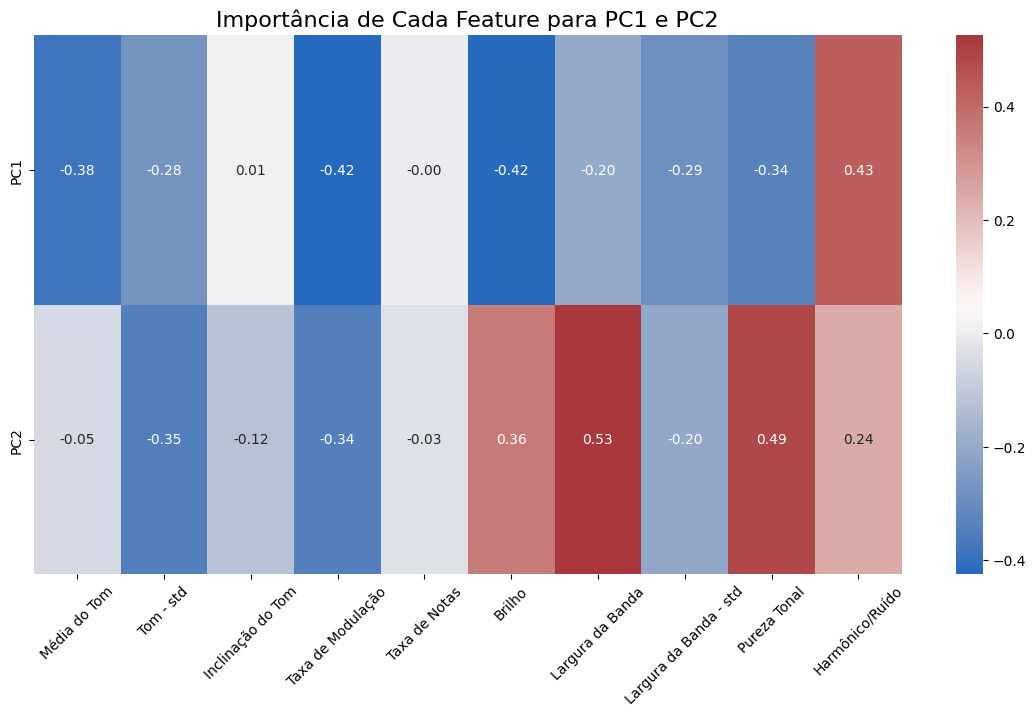

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titulos = ["Média do Tom", "Tom - std", "Inclinação do Tom", "Taxa de Modulação", "Taxa de Notas", "Brilho", "Largura da Banda", "Largura da Banda - std", "Pureza Tonal", "Harmônico/Ruído"]

# -------------------------------------------------------------------
# ANALISANDO OS COMPONENTES (LOADINGS)
# -------------------------------------------------------------------
# Esta análise assume que 'pca' e 'features_to_analyze'
# ainda estão na memória da Célula 6.

print("--- Cargas dos Componentes Principais (PCA Loadings) ---")
print("O que o PC1 e o PC2 realmente significam?\n")

try:
    # Pega os "pesos" (cargas) do modelo PCA
    loadings = pca.components_

    # Cria um DataFrame para visualizar
    df_loadings = pd.DataFrame(
        loadings,
        columns=features_to_analyze,
        index=['PC1', 'PC2']
    )

    # Exibe o DataFrame
    print(df_loadings)

    # -------------------------------------------------------------------
    # VISUALIZAÇÃO DOS LOADINGS (HEATMAP)
    # -------------------------------------------------------------------
    print("\n--- Visualização (Heatmap) dos Loadings ---")

    plt.figure(figsize=(14, 7))
    sns.heatmap(df_loadings, annot=True, cmap='vlag', fmt='.2f', xticklabels=titulos)
    plt.title('Importância de Cada Feature para PC1 e PC2', fontsize=16)
    plt.xticks(rotation=45)
    plt.show()

except NameError:
    print("❌ ERRO: 'pca' ou 'features_to_analyze' não encontrados.")
    print("Por favor, rode a Célula 6 (PCA) primeiro.")

##Significado



**Média do Tom:** A média da frequência fundamental (pitch) do canto.

**Variação do Tom:** O desvio padrão do tom (o quão "trêmulo" ou "ondulado" é).

**Inclinação do Tom:** A direção da melodia (se o canto tende a subir ou descer)

**Taxa de Modulação:** A velocidade média das mudanças rápidas no tom (vibração)

**Taxa de Notas:** O número de notas ou sílabas por segundo (ritmo).

**Brilho:** O "centro de massa do som. Valores altos = som "brilhante" (mais agudo).

**Largura de Banda:** O quão "largo" ou "espalhado" o som é no espectro.

**Variação da Largura de Banda:** O quanto a "largura" do som muda durante o canto.

**Pureza Tonal:** Mede "pureza" vs. "ruído". Baixa entropia = tom puro. Alta entropia = som "ruído".

**Relação Harmônico/Ruído:** A proporção de energia "limpa" (harmônicos) vs. "suja" (ruído).

Por que 2 componentes?

--- Gráfico de Variância Explicada (Scree Plot) ---


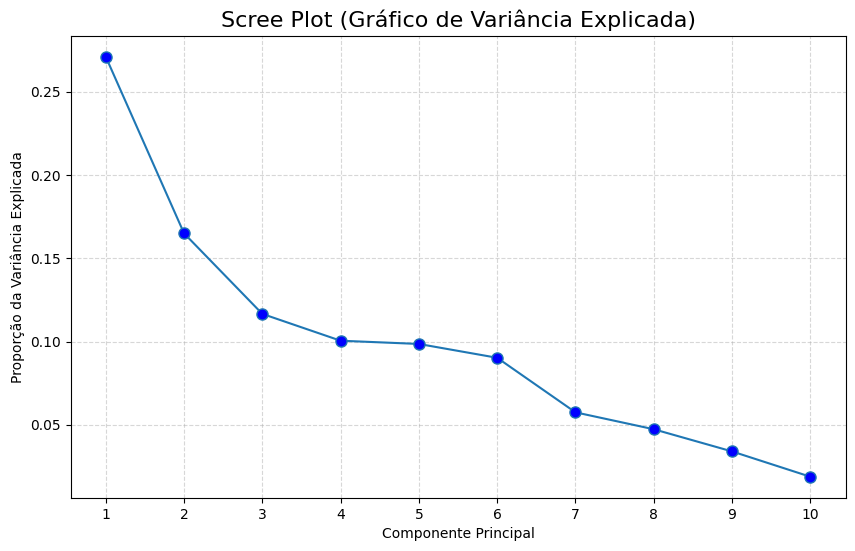


Variância do PC1: 27.11%
Variância do PC2: 16.50%
Variância do PC3: 11.66%


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------------------------------------------------
# RE-RODAR O PCA (PARA PEGAR TODOS OS COMPONENTES)
# -------------------------------------------------------------------
# Esta análise assume que 'X_scaled' (seus dados padronizados)
# está na memória da Célula 6.

print("--- Gráfico de Variância Explicada (Scree Plot) ---")

try:
    # Roda o PCA de novo, mas sem limite de componentes
    pca_full = PCA(n_components=None)
    pca_full.fit(X_scaled)

    # Pega a variância explicada de CADA componente
    explained_variance = pca_full.explained_variance_ratio_

    # -------------------------------------------------------------------
    # 2. PLOTAR O "SCREE PLOT"
    # -------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'o-', markerfacecolor='blue', markersize=8)
    plt.title('Scree Plot (Gráfico de Variância Explicada)', fontsize=16)
    plt.xlabel('Componente Principal')
    plt.ylabel('Proporção da Variância Explicada')
    plt.xticks(range(1, len(explained_variance) + 1))
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    print(f"\nVariância do PC1: {explained_variance[0]:.2%}")
    print(f"Variância do PC2: {explained_variance[1]:.2%}")
    print(f"Variância do PC3: {explained_variance[2]:.2%}")

except NameError:
    print("❌ ERRO: 'X_scaled' não encontrado.")
    print("Por favor, rode a Célula 6 (PCA) primeiro.")

Vendo o "cotovelo" (Elbow), o gráfico "cai" drasticamente do PC1 para o PC2, e depois do PC2 para o PC3, e então se achata. Isso prova que a maior parte da "informação" estava nos dois primeiros componentes.

Vamos "forçar" grupos para verificar que não há como separar dialetos diferentes, mais uma vez reforçando a hipótese clinal:

--- Teste de Hipótese: Provando a 'Ausência de Dialetos' ---
Modelo K-Means treinado (k=3).

--- Resultado Estatístico ---
Pontuação de Silhueta (Silhouette Score): 0.3560

Interpretação:
-> Pontuação BAIXA.
-> Os 'clusters' se sobrepõem e são artificiais.
-> A variação é contínua (clinal), não discreta (dialetos).

--- Visualizando os 'Dialetos' Forçados ---


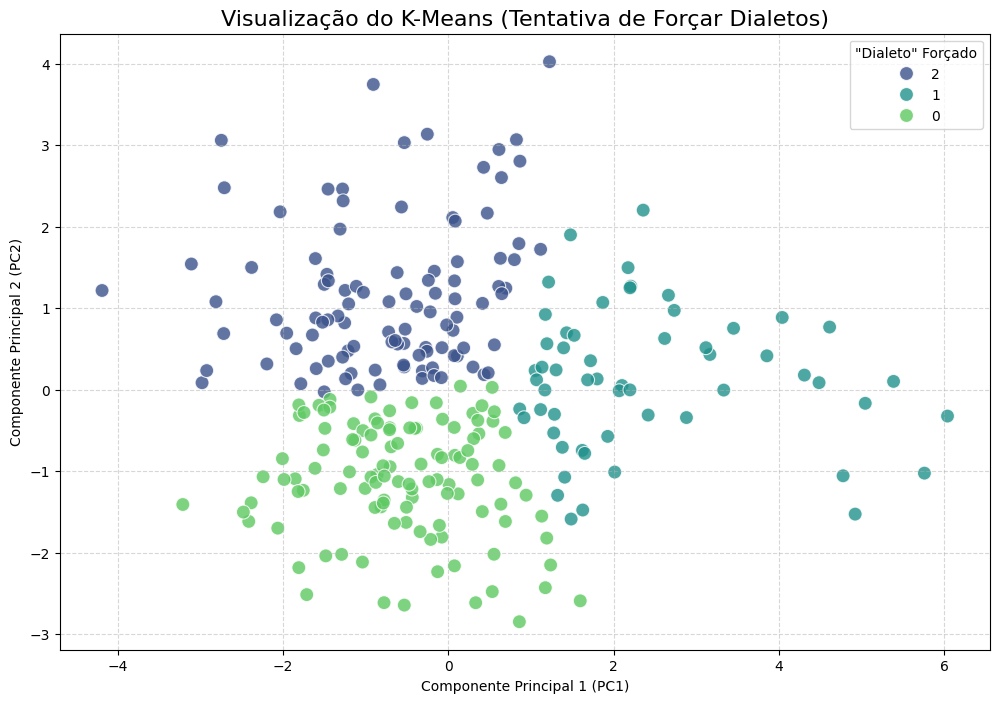

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -------------------------------------------------------------------
# USAR OS DADOS DO PCA (CÉLULA 6)
# -------------------------------------------------------------------
# Esta análise assume que 'df_pca' (com PC1, PC2, latitude)
# está na memória da Célula 6.
try:
    df_pca
except NameError:
    print("❌ ERRO: 'df_pca' não encontrado.")
    print("Por favor, rode a Célula 6 (PCA) primeiro.")
    raise

# Nossos dados são os "mapas" do canto
X_pca_data = df_pca[['PC1', 'PC2']]

print("--- Teste de Hipótese: Provando a 'Ausência de Dialetos' ---")

# -------------------------------------------------------------------
# APLICAR K-MEANS
# -------------------------------------------------------------------
# Vamos tentar forçar os dados em 3 "dialetos" (k=3)
k = 3
kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_model.fit(X_pca_data)

# Adiciona os "dialetos" previstos ao nosso DataFrame
df_pca['cluster'] = kmeans_model.labels_
df_pca['cluster'] = df_pca['cluster'].astype(str) # Para o gráfico

print(f"Modelo K-Means treinado (k={k}).")

# -------------------------------------------------------------------
# AVALIAÇÃO ESTATÍSTICA (SILHOUETTE SCORE)
# -------------------------------------------------------------------
# Esta é a prova. Score perto de 0 = vitória.
score = silhouette_score(X_pca_data, kmeans_model.labels_)

print(f"\n--- Resultado Estatístico ---")
print(f"Pontuação de Silhueta (Silhouette Score): {score:.4f}")

print("\nInterpretação:")
if score > 0.5:
    print("-> Pontuação ALTA. Isso sugere que os dialetos SÃO reais e discretos.")
else:
    print("-> Pontuação BAIXA.")
    print("-> Os 'clusters' se sobrepõem e são artificiais.")
    print("-> A variação é contínua (clinal), não discreta (dialetos).")

# -------------------------------------------------------------------
# VISUALIZAÇÃO DOS "DIALETOS" FALSOS
# -------------------------------------------------------------------
print("\n--- Visualizando os 'Dialetos' Forçados ---")

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='cluster', # Cor por "dialeto"
    palette='viridis',
    legend='full',
    s=100,
    alpha=0.8
)

# Plota os centros (centróides) dos clusters
#centers = kmeans_model.cluster_centers_
#plt.scatter(centers[:, 0], centers[:, 1], c='red', s=250, marker='X', label='Centros dos Clusters')

plt.title('Visualização do K-Means (Tentativa de Forçar Dialetos)', fontsize=16)
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.legend(title='"Dialeto" Forçado')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

O algoritmo K-Means tentou encontrar 3 grupos, mas falhou em encontrar grupos "bons". Isso confirma a hipótese de que a variação é um gradiente contínuo (clinal), e não um conjunto de grupos discretos.